<a href="https://colab.research.google.com/github/magish-gautam/Magish-Concept-of-AI/blob/Workshop-2/Worksheet6_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training Logistic Regression Model:
Iteration 0: Cost = 0.676575
Iteration 100: Cost = 0.465441
Iteration 200: Cost = 0.455913
Iteration 300: Cost = 0.453874
Iteration 400: Cost = 0.453316
Iteration 500: Cost = 0.453148
Iteration 600: Cost = 0.453096
Iteration 700: Cost = 0.453079
Iteration 800: Cost = 0.453074
Iteration 900: Cost = 0.453072
Iteration 999: Cost = 0.453071


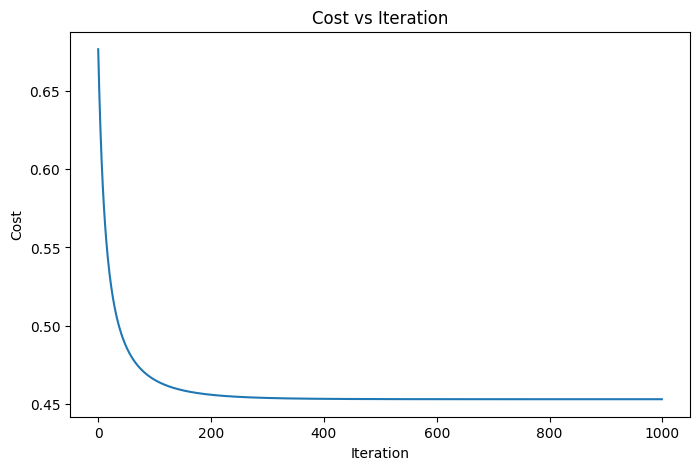


Train Loss (Cost): 0.4531
Test Loss (Cost): 0.5146

Test Accuracy: 70.78%

Confusion Matrix:
 [[82 18]
 [27 27]]
Precision: 0.60
Recall: 0.50
F1-score: 0.55


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Sigmoid / Logistic Function
def logistic_function(x):
    return 1 / (1 + np.exp(-x))

# 2. Log Loss Function
def log_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    return -y_true * np.log(y_pred) - (1 - y_true) * np.log(1 - y_pred)

# 3. Cost Function (Average Log Loss)
def cost_function(y_true, y_pred):
    n = len(y_true)
    loss_vec = log_loss(y_true, y_pred)
    return np.sum(loss_vec) / n

# 4. Vectorized Cost Function for Logistic Regression
def costfunction_logreg(X, y, w, b):
    z = np.dot(X, w) + b
    y_pred = logistic_function(z)
    return cost_function(y, y_pred)

# 5. Compute Gradient (Vectorized)
def compute_gradient(X, y, w, b):
    n, d = X.shape
    z = np.dot(X, w) + b
    y_pred = logistic_function(z)

    grad_w = (1/n) * np.dot(X.T, (y_pred - y))
    grad_b = (1/n) * np.sum(y_pred - y)

    return grad_w, grad_b

# 6. Gradient Descent Training
def gradient_descent(X, y, w, b, alpha, n_iter, show_cost=False, show_params=True):
    cost_history = []
    params_history = []

    for i in range(n_iter):
        grad_w, grad_b = compute_gradient(X, y, w, b)
        w -= alpha * grad_w
        b -= alpha * grad_b

        cost = costfunction_logreg(X, y, w, b)
        cost_history.append(cost)
        params_history.append((w.copy(), b))

        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

        if show_params and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: w = {w}, b = {b:.6f}")

    return w, b, cost_history, params_history

# 7. Prediction Function
def prediction(X, w, b, threshold=0.5):
    z = np.dot(X, w) + b
    y_prob = logistic_function(z)
    return (y_prob >= threshold).astype(int)

# 8. Evaluation Function
def evaluate_classification(y_true, y_pred):
    TN = np.sum((y_true == 0) & (y_pred == 0))
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    confusion_matrix = np.array([[TN, FP],
                                 [FN, TP]])

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return confusion_matrix, precision, recall, f1_score


# ----- MODEL PIPELINE -----

# Load dataset from internet (FIXED)
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
data_pima_diabetes = pd.read_csv(url, names=columns)

# Cleaning
cols_clean = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data_pima_diabetes[cols_clean] = data_pima_diabetes[cols_clean].replace(0, np.nan)
data_pima_diabetes.fillna(data_pima_diabetes.median(), inplace=True)

# Train-test split
X = data_pima_diabetes.drop(columns=['Outcome']).values
y = data_pima_diabetes['Outcome'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize parameters
w = np.zeros(X_train_scaled.shape[1])
b = 0.0
alpha = 0.1
n_iter = 1000

# Train
print("\nTraining Logistic Regression Model:")
w, b, cost_history, params_history = gradient_descent(X_train_scaled, y_train, w, b, alpha, n_iter, show_cost=True, show_params=False)

# Plot convergence
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.show()

# Evaluate
y_train_pred = prediction(X_train_scaled, w, b)
y_test_pred = prediction(X_test_scaled, w, b)

train_cost = costfunction_logreg(X_train_scaled, y_train, w, b)
test_cost = costfunction_logreg(X_test_scaled, y_test, w, b)

print(f"\nTrain Loss (Cost): {train_cost:.4f}")
print(f"Test Loss (Cost): {test_cost:.4f}")

test_accuracy = np.mean(y_test_pred == y_test) * 100
print(f"\nTest Accuracy: {test_accuracy:.2f}%")

conf_matrix, precision, recall, f1 = evaluate_classification(y_test, y_test_pred)
print("\nConfusion Matrix:\n", conf_matrix)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
